In [1]:
import pandas as pd
import glob

cols = ['open_time','open','high','low','close','volume',
        'close_time','quote_volume','trades','taker_buy_base',
        'taker_buy_quote','ignore']

BASE = '/home/onyxia/work/binance-public-data/python/data/spot/monthly/klines'

def load_symbol(symbol):
    files = sorted(glob.glob(f'{BASE}/{symbol}/1h/**/*.zip', recursive=True))
    print(f"{symbol}: {len(files)} fichiers trouvés")
    dfs = [pd.read_csv(f, names=cols) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    t = pd.to_numeric(df['open_time'], errors='coerce')
    df = df[t.notna()]
    t = t[t.notna()]
    t = (t / 1000).where(t > 1e14, t)
    df['open_time'] = pd.to_datetime(t, unit='ms')

    df = df.set_index('open_time').sort_index()
    return df['close'].astype(float).rename(symbol)

btc = load_symbol('BTCUSDT')
eth = load_symbol('ETHUSDT')
sol = load_symbol('SOLUSDT')

prices = pd.concat([btc, eth, sol], axis=1).dropna().reset_index()
print(prices.shape)

BTCUSDT: 6 fichiers trouvés
ETHUSDT: 6 fichiers trouvés
SOLUSDT: 6 fichiers trouvés
(4344, 4)


In [2]:
prices.head(20)

,open_time,BTCUSDT,ETHUSDT,SOLUSDT
0,2025-01-01 00:00:00,94401.14,3363.70,192.54
1,2025-01-01 01:00:00,93607.74,3346.54,190.70
2,2025-01-01 02:00:00,94098.91,3362.61,191.59
3,2025-01-01 03:00:00,93838.04,3355.20,190.43
4,2025-01-01 04:00:00,93553.91,3341.14,189.47
5,2025-01-01 05:00:00,93792.02,3345.41,190.15
6,2025-01-01 06:00:00,93757.58,3346.60,190.30
7,2025-01-01 07:00:00,93684.10,3347.12,190.06
8,2025-01-01 08:00:00,93428.46,3337.01,189.40
9,2025-01-01 09:00:00,93413.06,3334.64,189.18


In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

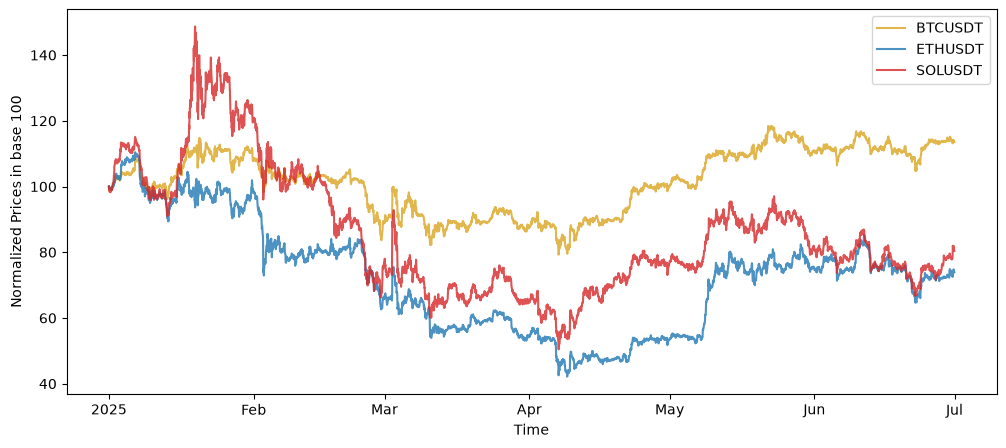

In [4]:
locator = mdates.AutoDateLocator()


fig,ax=plt.subplots(figsize=(12,5))
colors={
    'BTCUSDT':'goldenrod',
    'ETHUSDT':'tab:blue',
    'SOLUSDT':'tab:red'}
for col,color in colors.items():
    ax.plot(prices['open_time'],
    prices[col]/(prices[col].iloc[0])*100, #To be on the same scale, we compare their evolution, not their level
    color=color,
    label=col,
    alpha=0.8)
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Prices in base 100")
ax.legend()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.show()
    




In [6]:
import numpy as np

In [5]:
prices["log_prices"]=np.log(price['open_time'])

NameError: name 'np' is not defined